### Obtain the map ddqdtdt = F(q, dqdt^2)

Let us first load the training data

In [1]:
import pickle

file_path = 'DuffinType_Data.pkl'
with open(file_path,'rb') as f:
   Output,Input,dt,T = pickle.load(f) 

Output.shape, Input.shape

((19998, 1), (19998, 2))

In [2]:
import numpy as np

scale_in, scale_out = np.zeros(Input.shape[1]), np.zeros(Output.shape[1])

Input_rescale, Output_rescale = Input, Output

for j in range(Input.shape[1]):
    scale_in[j] = 1/np.max(np.abs(Input[:,j]))
    Input_rescale[:,j] = scale_in[j]*Input[:,j]

for j in range(Output.shape[1]):
    scale_out[j] = 1/np.max(np.abs(Output[:,j]))
    Output_rescale[:,j] = scale_out[j]*Output[:,j]

np.max(np.abs(Input_rescale[:,0])), np.max(np.abs(Input_rescale[:,1])), np.max(np.abs(Output_rescale[:,0])), scale_in, scale_out

(np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 array([0.4471795 , 0.12441184]),
 array([0.1117737]))

In [3]:
# Now make them Torch tensor
import torch
Tensor_Input = torch.tensor(Input_rescale, dtype=torch.float32)
Tensor_Output = torch.tensor(Output_rescale, dtype=torch.float32)

# The shape should be, number of samples times input dimensions; also demonstrate how to select 
Tensor_Input.shape, Tensor_Output.shape

(torch.Size([19998, 2]), torch.Size([19998, 1]))

### 1. Create the Neural Network

Now let us generating the neural network architectures

In [4]:
import torch.nn as nn

# Set device to CPU
device = torch.device('cpu')

# Set the random seed for reproducibility
torch.manual_seed(37)

# Create the Multi-Layers Perceptron

class Network1(nn.Module):
    
    def __init__(self):
        super(Network1, self).__init__()
        
        self.fcE1 = nn.Linear(2, 64)  # Input layer to first hidden layer
        #self.fcE2 = nn.Linear(64, 64)  # First hidden layer to second hidden layer
        self.fcE3 = nn.Linear(64, 1)  # Second hidden layer to output layer
        self.activation = nn.Tanh()
        #self.output_activation = nn.ReLU()

    def forward(self,x):
        x = self.activation(self.fcE1(x))  
        #x = self.activation(self.fcE2(x))
        x = self.fcE3(x)
        return x
    
F_NN = Network1().to(device)

### 2. Packaging the data for training

Before training the network, we need to package the data correctly. 

We need to split them into two sets -- one is the training set, the other is the validation set.

In [5]:
from torch.utils.data import DataLoader, TensorDataset, random_split

# Combine input and target tensors into a dataset
Total_Data = TensorDataset(Tensor_Input, Tensor_Output)

# Specify the size of the validation set (e.g., 10% of the entire dataset)
validation_ratio = 0.1
validation_size = int(validation_ratio * len(Total_Data))
training_size = len(Total_Data) - validation_size

# Split the dataset into training and validation sets
Training_Set, Validation_Set = random_split(Total_Data, [training_size, validation_size])

# Define the batch size
BATCH_SIZE = 1024
# Create data loaders for training and validation sets
Train_Loader = DataLoader(Training_Set, batch_size=BATCH_SIZE, shuffle=True)
Valid_Loader = DataLoader(Validation_Set, batch_size=BATCH_SIZE) #no need to shuffle, unseen anyway

### 3. Neural Network Training

Now we need to train the network for real

In [6]:
from torch import optim

# define loss function and optimization method
parameters = list(F_NN.parameters())
optimizer = optim.Adam(parameters, lr=5e-4)

mse = nn.MSELoss()

# Define the number of epochs
N_EPOCHS = 2*10**3
Epoch_List = np.arange(N_EPOCHS)+1
Train_Loss_List = np.zeros((N_EPOCHS))
Valid_Loss_List = np.zeros((N_EPOCHS))

# How frequent should it report answer
N_REP = 10**2

for epoch in range(N_EPOCHS):
    
    Train_Loss = 0.0
    # Loop over batches in an epoch using DataLoader
    for id_batch, (Input_Data, Output_Data) in enumerate(Train_Loader):
        # Clear the gradients for optimizer, or PyTorch will accumulate it
        optimizer.zero_grad()
        # Find the Loss
        r1 = F_NN(Input_Data) - Output_Data 
        Loss = mse(r1, torch.zeros_like(r1))
        # Calculate gradients 
        Loss.backward()
        # Update Weights
        optimizer.step()
        # Calculate Loss
        Train_Loss += Loss.item()
    Train_Loss_List[epoch] = Train_Loss/len(Train_Loader)

    Valid_Loss = 0.0
    # Loop over validation set
    for Input_Data, Output_Data in Valid_Loader:
        # Find the Loss
        r1 = F_NN(Input_Data) - Output_Data 
        Loss = mse(r1, torch.zeros_like(r1))
        # Calculate Loss
        Valid_Loss += Loss.item()
    Valid_Loss_List[epoch] = Valid_Loss/len(Valid_Loader)

    # Regularity of reporting answers
    if epoch % N_REP == 0:
        print(f'Epoch {epoch+1} \t Training Loss: {Train_Loss_List[epoch]} \t Validation Loss: {Valid_Loss_List[epoch]}')

Epoch 1 	 Training Loss: 0.026773516606125567 	 Validation Loss: 0.018888726830482483
Epoch 101 	 Training Loss: 0.0011952951511678596 	 Validation Loss: 0.001120662607718259
Epoch 201 	 Training Loss: 0.0003948563519063302 	 Validation Loss: 0.0003886628110194579
Epoch 301 	 Training Loss: 0.00028928546493666037 	 Validation Loss: 0.0002871847682399675
Epoch 401 	 Training Loss: 0.0002148879397686364 	 Validation Loss: 0.00021382344857556745
Epoch 501 	 Training Loss: 0.0001624744076656902 	 Validation Loss: 0.00015829846233827993
Epoch 601 	 Training Loss: 0.00011324862943082635 	 Validation Loss: 0.0001127701070799958
Epoch 701 	 Training Loss: 6.88555361800051e-05 	 Validation Loss: 6.951355317141861e-05
Epoch 801 	 Training Loss: 3.552608601845956e-05 	 Validation Loss: 3.6005943911732174e-05
Epoch 901 	 Training Loss: 1.7743173985864916e-05 	 Validation Loss: 1.8865446691052057e-05
Epoch 1001 	 Training Loss: 1.3803364153217342e-05 	 Validation Loss: 1.4123773780738702e-05
Epoch 

See the learning processs

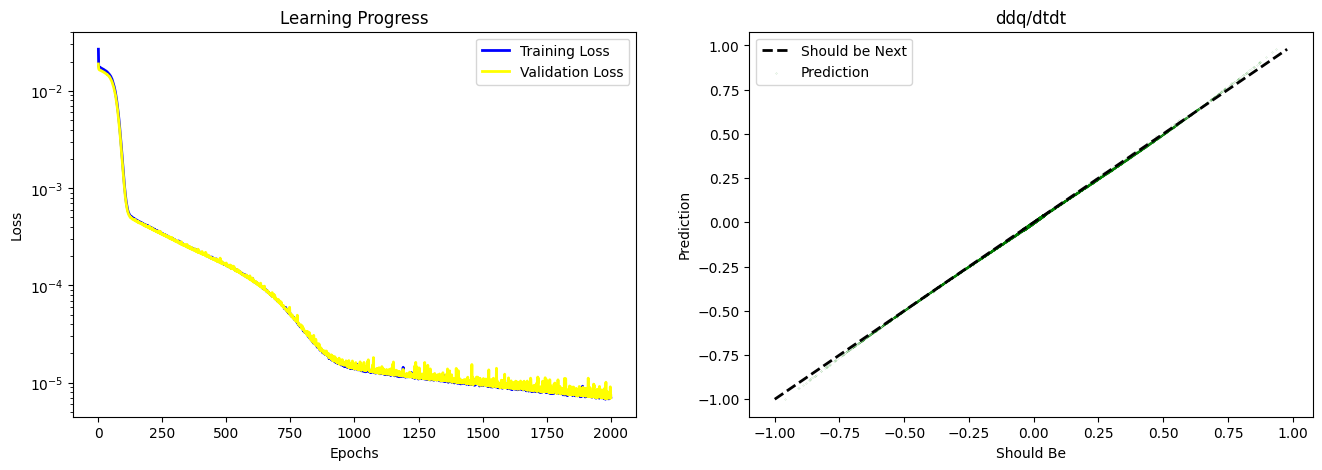

In [7]:
import pylab as pl

f1 = pl.figure(figsize=(16,5))
sf1_1, sf1_2 = f1.add_subplot(1,2,1), f1.add_subplot(1,2,2)

sf1_1.plot(Epoch_List,Train_Loss_List, linewidth=2, color='blue', label='Training Loss')
sf1_1.plot(Epoch_List,Valid_Loss_List, linewidth=2, color='yellow', label='Validation Loss')
sf1_1.set_title('Learning Progress')
sf1_1.set_xlabel('Epochs')
sf1_1.set_ylabel('Loss')
sf1_1.set_yscale('log')
sf1_1.legend()

Output_predict = F_NN(Tensor_Input).detach().numpy()
Output_shouldbe = Tensor_Output.detach().numpy()

sf1_2.plot([np.min(Output_shouldbe), np.max(Output_shouldbe)],[np.min(Output_shouldbe), np.max(Output_shouldbe)], linewidth=2, linestyle='--', color='black', label='Should be Next')
sf1_2.scatter(Output_predict, Output_shouldbe, color='green', s=0.02, alpha = 0.5, label='Prediction')
sf1_2.set_title('ddq/dtdt')
sf1_2.set_xlabel('Should Be')
sf1_2.set_ylabel('Prediction')
sf1_2.legend()

pl.show()

Save this training neural network

In [8]:
torch.save(F_NN.state_dict(), 'F_NN_ddt_Normalize.pth')

import pickle
file_path = 'F_NN_Scale.pkl'
with open(file_path,'wb') as f:
    pickle.dump((scale_in, scale_out),f)